# **Geophysics Lab 5: Locating Earthquakes**
Name: Firstname Lastname

**If you don't put your name in both the spot above AND the filename, you will not receive a grade for this lab.** Double-click this cell to add your name, run the cell when you're done. In the filename, **do not put any spaces between words or wildcard characters**. I will not be grading labs in different file formats or with spaces/wildcards in the file names.

In [ ]:
# run this cell to import some of the packages needed to complete this lab:
import numpy as np               # more on numpy here:       https://numpy.org/doc/stable/user/absolute_beginners.html
import matplotlib.pyplot as plt  # more on matplotlib here:  https://matplotlib.org/stable/users/explain/quick_start.html
import pandas as pd              # more on pandas here:      https://pandas.pydata.org/docs/

This lab will require you to import the data file `travel_times.csv` and use it. **Please make sure that you have downloaded the data file and put it into the same folder as this lab** (you need to do this so I don't have to re-path everyone's code when I grade it).

In [ ]:
# we are importing some other packages 'early' to see if you will have any issues with imports in this lab:
import obspy                           # more on obspy here: https://docs.obspy.org/
from obspy.clients.fdsn import Client  # sub-package of obspy
from obspy import UTCDateTime          # sub-package of obspy

# if this cell returns an error, you might not have the necessary packages installed. 
# if you can't figure out the installation, please contact your TA ASAP!

In this lab, we will be using two different methods (triangulation and grid search) to find the location of an earthquake epicenter. This lab consists of two sections with questions for you to answer throughout both sections. Please make sure you read and address all parts of each question.

## Section 1: Triangulation
Distance $d$, time $t$, and velocity $v$ are simply related by

\begin{equation}
\tag{1.1}
d = v t.
\end{equation}

Therefore, a P-wave traveling for time $t$ at velocity $V_P$ will move across a distance $r$, where $r$ is given by
\begin{equation}
\tag{1.2}
r = V_P t.
\end{equation}

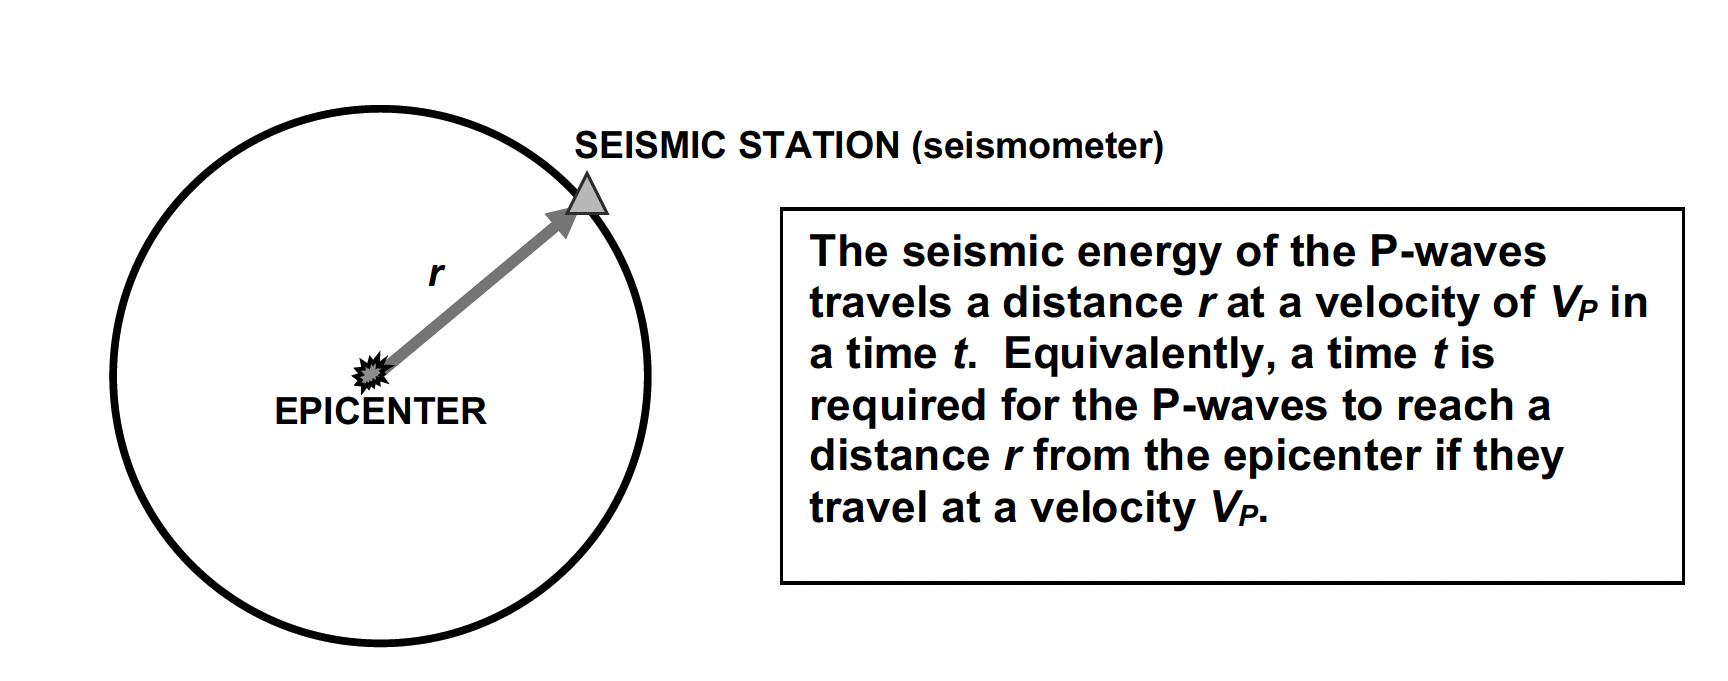

The time necessary for the P-wave to travel a distance r can be obtained by dividing equation (2) by $V_P$:
\begin{equation}
\tag{1.3}
t = \frac{r}{V_P}.
\end{equation}

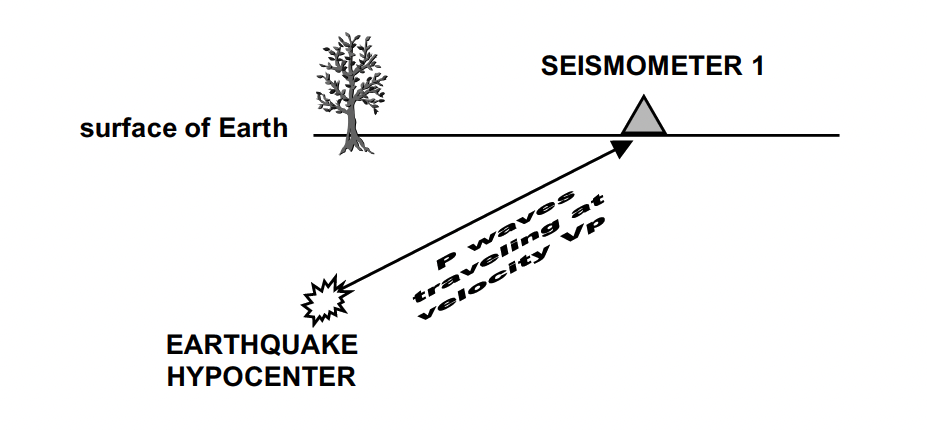

If a P-wave is generated from an earthquake (EQ) at the origin time $𝑇_0$ (the time the earthquake starts), the first wiggle on the seismogram will arrive at the observation station labeled “seismometer 1”, at a distance $r_1$ from the earthquake, at the time $T_0$ given by
\begin{equation}
\tag{1.4}
T_p^1 = T_0 + \frac{r_1}{V_P}
\end{equation}

where the superscript 1 indicates the seismometer.

In equation (1.4), the first term on the right-hand side (RHS) is the start time of the EQ, and the second term on the RHS is the time it takes the P-wave ray to reach the seismometer located at a distance $r_0$ from the EQ.

Similarly, an S-wave from the same earthquake traveling at a velocity $V_S$ will arrive at seismometer 1 at time $T_S^1$, given by 
\begin{equation}
\tag{1.5}
T_s^1 = T_0 + \frac{r_1}{V_S}
\end{equation}

Since S-waves travel more slowly than P-waves, $T_S^1 > T_P^1$.

Now we have a problem. Equations (1.4) and (1.5) both contain the unknown origin time $T_0$ . However, if we subtract equation (1.4) from equation (1.5), we eliminate $T_0$ and obtain the following very useful result:
\begin{equation}
\tag{1.6}
T_S^1 - T_P^1 = \frac{r_1}{V_S} - \frac{t_1}{V_P} = r_1 (\frac{1}{V_S} - \frac{1}{V_P}).
\end{equation}

**Equation (1.6) defines the S-P time (“S minus P time”) for the event as recorded at seismometer 1**: $T_{s-p} = T_S^1 - T_P^1$. We will use $T_{s-p}^1$ to represent the S-P time for this event at station 1.

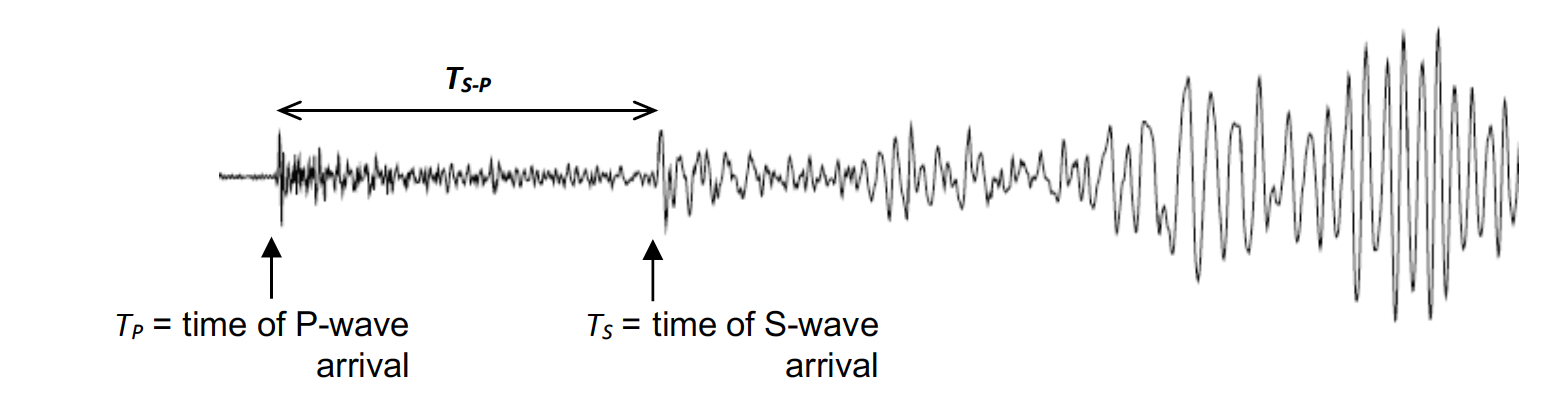

The S-P time depends on the distance from the earthquake to the seismic station and the relative times between the P and S wave, which can be variable based on 3D earth structure.

As part of Lab 2: you calculated P and S wave traveltime curves for an earthquake located 10 km below the surface. Your plot should have looked something like this:

In [ ]:
# what your lab 2 should've gotten you for travel times:
x  = np.linspace(0,45,10)       # epicentral distance vector, [km]
h  = 10                         # source depth,               [km]
d  = np.sqrt(h**2 + x**2)       # source-station distances,   [km]
vp = 6                          # primary wave velocity,      [km/s]
vs = 4                          # secondary wave velocity,    [km/s]

tp = d/vp                       # primary wave travel time,   [s]
ts = d/vs                       # secondary wave travel time, [s]

plt.figure(figsize = (10, 4), dpi = 300)
plt.plot(x, tp, label='primary wave')
plt.plot(x, ts, label='secondary wave')
plt.title('Travel Time Curves from Lab 2')
plt.legend()
plt.grid()
plt.xlabel('epicentral distance [km]')
plt.ylabel('time [s]')
plt.xlim(0,45)
plt.show();

**Question 1.1:** \
What happens to the S-P travel time as you get farther away from the epicenter? _(1 point)_

_Double-click this cell and replace this text with your answers to Question 1.1. Run the cell when you're done._

**Question 1.2**:\
An earthquake is recorded at two seismic stations, station A and station B. If station A is 10 km from the epicenter (point on Earth’s surface directly above where the earthquake rupture began), and station B is 100 km from the epicenter, which station will exhibit a larger S-P time? _(1 point)_

_Double-click this cell and replace this text with your answers to Question 1.2. Run the cell when you're done._

Comparing equations (1.3) and (1.6), you may notice that the time separation between the **P-wave arrival** (peak on the seismogram corresponding to the first arrival of a P-wave at the seismometer) and the **S-wave arrival** (peak on the seismogram corresponding to the first arrival of an S-wave at the seismometer) has an effective velocity by which it increases with distance:

\begin{equation}
\tag{1.7}
V_{s-p} = \dfrac{1}{ \frac{1}{V_S} - \frac{1}{V_P} } .
\end{equation}

The quantity  $V_{s-p}$ is called the **effective S-P velocity**.

Therefore, the distance $r_1$ from seismometer 1 to the earthquake can be computed from seismograms (P-wave and S-wave arrival times) as
\begin{equation}
\tag{1.8}
r_1 = V_{s-p}T^1_{s-p},
\end{equation}

where $ T^1_{s-p} $ is measured on a seismogram, but $ V_{s-p} $ is based on knowledge of Earth properties, as values for both $V_P$ and $V_S$ are necessary to make this calculation (equation 1.7). In other words, we need to have some idea of the P-wave and S-wave velocities in the Earth.

We are going to download data from the [IRIS DMC](https://ds.iris.edu/ds/nodes/dmc/) data center. The data was collected from the [Pacific Northwest Seismic Network](https://pnsn.org/). We focus on the M 6.8 February 28, 2001 Nisqually earthquake.

In [ ]:
# create the link between you and the IRIS-DMC
client    = Client('IRIS')                 # refer to the import cells at the top if you're confused about what 'Client' is

# Origin time of the Nisqually earthquake   
s1 = obspy.UTCDateTime(2001,2,28,18,54,37) # again, refer to the import cells at the top of this notebook      

# collect the information about what data is available
inv = client.get_stations(network="UW",station="*",channel="BHZ",location="*",starttime=s1,endtime=s1+86400)
print(inv)

# create a list of the stations you found
sta=list()
for k in inv:
    for sta1 in k:
        sta.append(sta1.code)
        
# print the list of the stations we would be using
print("The stations we will be using are:")
print(sta)

Mapping in python requires a few more packages (which you probably don't want to install...), so we found a map of where these stations are on the IRIS-GMAP tool https://ds.iris.edu/gmap and annotated the stations.

Let's search using the network/station names provided below. (You can copy-paste them.) 
- **Network:** UW
- **Station:** GNW,LON,LTY,RWW,SEP,SQM,TTW

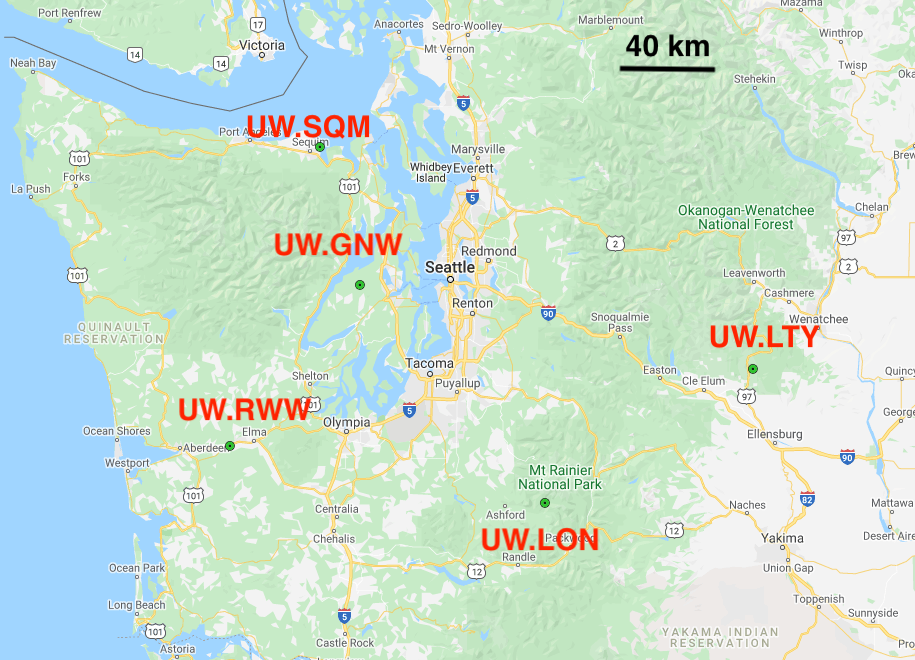

In [ ]:
# download data:
tr=obspy.Stream()
# we will update sta to make sure we have all of the stations

# create a list of the stations you found
sta1=list()

for ista in sta:
    try:
        tr += client.get_waveforms(network="UW",station=ista,channel="*HZ",location="*",starttime=s1,endtime=s1+100)
        sta1.append(tr[-1].stats.station)
        print(tr[-1].stats.station)
        
    except:
        pass
    
# we actually have fewer stations
print(sta1)
sta=sta1

In [ ]:
# we can use matplotlib
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6) #bigger size of figures as defaults

####
itr=0 # you can change and make it range from 0 to len(tr)-1
###
# create a time vector of 60 seconds (1 minute), sampled at the sampling rate of the data.
t=np.linspace(0,60,int(60/tr[itr].stats.delta))

# plot the data
plt.figure(figsize=(12,5),dpi=300)
plt.plot(t,tr[itr].data[:len(t)]/np.max(np.abs(tr[itr].data)),'k') # normalized data
plt.title(tr[itr].stats.station)
plt.xlabel('Time in (s)')
plt.grid(True)
plt.xlim([0,60]) # <- you can mess with this to zoom in on a specific time
plt.show();

Now we can plot each of the data one by one. ``tr`` is an **array** of seismic ***streams***. ***Streams*** are basically **Obspy** objects that combine seismic station information and the time series. We can *iterate* through ``tr`` to plot each waveform. We can also zoom in on specific times to focus on different part of the waveforms.

In [ ]:
print("there are "+str(len(tr))+" seismograms from these stations") # here we use "str" to convert an integer (len) into a string

Now we are going to see how the overall waves compare to each other:

In [ ]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (18,12)
for ii,itr in enumerate(tr):
    if itr.stats.station == "SEP":continue # this station "clipped", meaning that the shaking was too intense for the instrument
    
    t   = np.linspace(0,60,int(60/itr.stats.delta))
    if len(itr.data)<len(t):continue
        
    crp = itr.copy()
    crp = crp.filter('bandpass',freqmin=1,freqmax=10) # <- you can play with that
    
    # plot the curves
    plt.plot(t,crp.data[:len(t)]/np.max(np.abs(crp.data))+ii,'k')
    plt.text(5,ii+0.1,itr.stats.station,fontsize=14,c='r') # if you're zooming in on curves, maybe comment this out temporarily

plt.grid(True)
plt.xlabel('Time in sec', fontsize=20)
plt.xlim([0, 60])
#plt.ylim([-1,1]) # <- you can play with this (to zoom in on a specific curve)
plt.show();

The figure above shows seismograms (data from seismometers) recording ground motion from the same earthquake at 5 different stations. A few things to note about this data:

* The vertical axis on the plot is the amplitude of ground motion. Individual seismograms or traces are scaled differently, and actually normalized.

* The waveforms may look jagged, instead of pure smooth oscillations. This is because this earthquake shaking was really, really strong and even damaged the soil. This was a very strongly felt earthquake with extensive damage.

* There is a high-frequency signal first, which is the P wave. The lower frequency that arrives next is likely the S wave.

**For the questions below, assume the earthquake is at the surface (z=0 km), so depth is not a factor.**

**Question 1.3:** \
Add the Primary wave arrivals to the plot for each seismogram: change the values in `arrivals_p` to match the time value for the P-wave arrival for each curve. Then do the same for the Secondary wave arrivals, in `arrivals_s`. Run the cells below to plot your estimates. _(5 points)_

**Do not change `arrivals_p[3] = 0` or `arrivals_s[3] = 0`, as that index is for the station that clipped.**

In [ ]:
# estimate the P wave arrival times for each station here:
GNW_P = ... # your estimate for the P wave arrival time at station GNW
LTY_P = ... # your estimate for the P wave arrival time at station LTY
RWW_P = ... # your estimate for the P wave arrival time at station RWW
SQM_P = ... # your estimate for the P wave arrival time at station SQM
TTW_P = ... # your estimate for the P wave arrival time at station TTW

arrivals_p = np.array([GNW_P, LTY_P, RWW_P, 0, SQM_P, TTW_P])  # P wave arrivals, stations are [ GNW , LTY , RWW , [clipped] , SQM , TTW ]
print("P wave arrivals: ", arrivals_p) 

# estimate the S wave arrival times for each station here:
GNW_S = ... # your estimate for the S wave arrival time at station GNW
LTY_S = ... # your estimate for the S wave arrival time at station LTY
RWW_S = ... # your estimate for the S wave arrival time at station RWW
SQM_S = ... # your estimate for the S wave arrival time at station SQM
TTW_S = ... # your estimate for the S wave arrival time at station TTW

arrivals_s = np.array([GNW_S, LTY_S, RWW_S, 0, SQM_S, TTW_S])  # S wave arrivals, stations are [ GNW , LTY , RWW , [clipped] , SQM , TTW ]
print("S wave arrivals: ", arrivals_s)

In [ ]:
pc_list = plt.cm.Reds(np.linspace(0.2,0.8,6))   # don't worry about it
sc_list = plt.cm.Blues(np.linspace(0.3,0.8,6))  # don't worry about it

plt.rcParams["figure.figsize"] = (18,12)
for ii,itr in enumerate(tr):
    if itr.stats.station == "SEP":continue # this station "clipped", meaning that the shaking was too intense for the instrument
    
    t   = np.linspace(0,60,int(60/itr.stats.delta))
    if len(itr.data)<len(t):continue
        
    crp = itr.copy()
    crp = crp.filter('bandpass',freqmin=1,freqmax=10)
    
    # plot the curves
    plt.vlines(arrivals_p[ii], ii, ii+1, colors=pc_list[ii], label=f"P wave arrival {itr.stats.station}", linewidth=5, alpha=0.7)
    plt.vlines(arrivals_s[ii], ii, ii+1, colors=sc_list[ii], label=f"S wave arrival {itr.stats.station}", linewidth=5,alpha=0.7)
    plt.plot(t,crp.data[:len(t)]/np.max(np.abs(crp.data))+ii,'k')
    plt.text(5,ii+0.1,itr.stats.station,fontsize=14,c='r') # if you're zooming in on curves, maybe comment this out temporarily

plt.grid(True)
plt.xlabel('Time in sec', fontsize=20)
plt.xlim([0, 60])
plt.ylim([-1,6])
plt.legend(loc='center right')
plt.show();

**Question 1.4:** \
Use your estimates of arrival times from the previous question to calculate the **S-P (differential) times** for each station, and store them as the python variables indicated in the cell below. _(2.5 points)_

In [ ]:
# Type your answer here, replacing "..." with your answer

# tp is P-wave travel time, ts is S-wave travel time
# tsp = ts - tp (all units in seconds) (first part of equation 1.6)

# fill ... for all stations
tsp_TTW = ... # T_s-p for station TTW
tsp_SQM = ... # T_s-p for station SQM
tsp_RWW = ... # T_s-p for station RWW
tsp_LTY = ... # T_s-p for station LTY
tsp_GNW = ... # T_s-p for station GNW

print(" TTW| SQM| RWW| LTY| GNW")
print("%.1f|%.1f|%.1f|%.1f|%.1f" % (tsp_TTW, tsp_SQM, tsp_RWW, tsp_LTY, tsp_GNW))

**Question 1.5:** \
Suppose $V_P$ = 6.0 km/s and $V_S$ = 3.47 km/s. These velocities are based on properties of the Earth’s crust. Use equation (1.7) to compute the effective $V_{s-p}$. Define and put your answer in a float variable called `v_sp`. _(1 point)_

In [ ]:
v_sp = ... # your calculation here 
print("effective V_sp = ", v_sp)

**Question 1.6:** \
Use equation (1.8), your computed value of $V_{s-p}$, and the S-P times that you measured for each station to calculate the distance from each station to the EQ that caused the ground motion recorded in the seismograms. _(2.5 points)_

In [ ]:
# Type your answer here, replacing "..." with your answer 

r_TTW = ... # for station TTW
r_SQM = ... # for station SQM
r_RWW = ... # for station RWW
r_LTY = ... # for station LTY
r_GNW = ... # for station GNW

print(" TTW  |  SQM  |  RWW |  LTY  |  GNW")
print("%.3f|%.3f|%.3f|%.3f|%.3f" % (r_TTW, r_SQM, r_RWW, r_LTY, r_GNW))

**Question 1.7:** \
On the map provided during the lab section, draw circles around each station with a radius corresponding to the $r$ that you computed for that station. The earthquake epicenter is where all the circles (or the most of them) **intersect** (intersect does not mean overlap, it means intersect). Mark this _single point_ with a star. This method of locating the earthquake epicenter is called triangulation. **Note that you only have data for some of the stations on the map.** 

Submit your scan of your drawing on Canvas with your assignment named `lab5_q17_FirstnameLastname.pdf` with your name in the designated spot, or hand it to the TA in lab to be graded. Your answer must be originally sketched on paper by hand to count for credit. _(4 points)_

**Question 1.8:** \
Give at least two reasons why the circles may not exactly cross at a single point. **Don't cite poor drawing** – think about the myriad sources of error throughout this process. _(2 points)_

_Double-click this cell and replace this text with your answers to question 1.8. Run the cell when you're done._

**Question 1.9:** \
What is the minimum number of S-P times needed to find the epicenter of an earthquake? Explain in words why your answer is correct. _(2 points)_

_Double-click this cell and replace this text with your answers to question 1.9. Run the cell when you're done._

## Section 2: Grid search
Now we are going to locate an earthquake in a different way. The difference between the observed travel time, or the travel time observed from seismic data, and the predicted travel time, or the travel time predicted from a model, is called the travel time residual. One method to find the location is to calculate the predicted travel times on a grid and find the grid point with the smallest residual. This is what we will do now.

The predicted travel time from an earthquake at ($x,y$) to the k$^{th}$ station with coordinates ($x_k,y_k$)
\begin{equation}
\tag{2.1}
t^p_k = \dfrac{\sqrt{ (x-x_k)^2 + (y-y_k)^2  }}{v},
\end{equation}

where $v$ is the appropriate seismic velocity. Note that the superscript $p$ here is not a power, but just denotes the predicted travel time.

You can also use the seismogram recorded at the k$^{th}$ station to find the real, or, **observed travel time**. One way to locate an earthquake is to minimize the difference between the travel times predicted from the model, $t^p$, and observed travel times, $t^o$. The expression for the travel time residual at the k$^{th}$ station is
\begin{equation}
\tag{2.2}
r_k = t_k^o - t_k^p
\end{equation}

where $t_k^o$ is the observed travel time at station k and $t_k^p$ is the predicted travel time at station k.

We are going to minimize the residuals for a whole network of stations using the method of **least squares**. Here we will define the **misfit** of a certain grid point as the sum of the squared residuals of each station
\begin{equation}
\tag{2.3}
\epsilon = \sum_{k=1}^n r_k^2
\end{equation}

where $n$ is the number of stations.

Our goal is to find the grid point with minimum misfit. We will do this by assuming an earthquake location ($x,y$) and calculating the misfit 𝜖 for that location. We do this for many trial locations, and then find the location that fits the data the best.

The table below has the location (x and y coordinates) of 13 stations, as well as the observed P wave travel times at each station.

We are going to read the travel-time data from the CSV file `travel_times.csv` using pandas. **Pandas** is a wonderful open-source python package to handle structured (tables) data. Here, the `Pwave travel-time` field means observed P-wave travel time.

In [ ]:
df = pd.read_csv("./travel_times.csv")
print(df)

In [ ]:
# Pandas data frames are great.
df.head() # shows the top 5 rows

In [ ]:
df.describe() # runs some basic stats on the data in the file.

In [ ]:
df['x'] # how to select the locations.

In [ ]:
np.asarray(df['x']) # convert the data frame column into a numpy array.

**Question 2.1:** \
Assume the P wave velocity is 6 km/s. The steps outlined below will help you write a program in Python that uses this information to locate the earthquake using a grid search. Perform your grid search on a 100x100 km grid (10,000 locations).


In the following, define variables: i) a P-wave velocity as a single scalar into `vp`, ii) the ``x`` and ``y`` arrays of spatial coordinate, with **values ranging from 1 to 100 with increment of 1**, iii) convert the stations coordinates and travel times from the pandas column into numpy arrays using the function above. _(2 points)_

In [ ]:
# Type your answer here, replacing "..." with your answer
vp = ...
x  = ...
y  = ...

# from the data frame df:
x_coord  = ... # station x coordinates
y_coord  = ... # station y coordinates
time_obs = ... # observed p wave travel times

print(f"There are {len(x)} points in x and {len(y)} points in y.")

Now we will initialize an abnormally large value of what residuals could be. We will update this value within a loop to only find the minimum residual among all possible locations.

In [ ]:
misfit_min = 1e9

**Question 2.2:** \
Use nested FOR loops to go through the x and y coordinates of your grid (e.g., outer loop goes through the x coordinates, inner loop goes through the y coordinates). _(4 points)_

With the for loop where we select ``i`` and ``j`` as indices for ``x`` and ``y``, you can check each potential earthquake source location of x and y. Calculate for each the distance between your trial earthquake location and each source-station distance.  For each potential earthquake location, please calculate:

* Distance between the potential earthquake location and each station
* Predict the travel time between the potential earthquake location and the station for P waves
* Compute the residual ``res`` between the observed and the predicted travel times (that is, the residuals).
* Sum all of the residuals over the 13 stations, and calculate the misfit as `misfit`.
* If that misfit is less than ``misfit_min``, update ``misfit_min=misfit`` and save the value of the indices (or location as ``i_best`` and ``j_best``).

See Lab 2 for FOR loop reference, and check out https://realpython.com/nested-loops-python/ if you're not sure what you're looking at.

In [ ]:
grid = np.zeros([len(x),len(y)]) # don't worry about this line

# Type your answer here, replacing "..." with your answer
for i in range(len(x)):
    for j in range(len(y)):
        ...
        res    = ... # calculate residuals
        misfit = ... # calculate the misfit
        
        grid[i,j] = misfit      # just storing your misfits for plotting later. Don't touch this line.
        if misfit < misfit_min:
            misfit_min = ...
            i_best     = ...
            j_best     = ...


# leave the print statement in, please:
print(f"The best location is found at i={i_best}, j={j_best}") # Don't touch this line.

**Question 2.3:** \
The best earthquake location is that found when the residuals are minimized. So where is the earthquake in the ``x`` and ``y`` space? Put your answer in a variable `source_x` and `source_y`. Then run the following cell to generate a plot with your source location, receiver locations, and the misfits for each grid cell. _(1 point)_

In [ ]:
source_x = ... # your answer for the x coord of the earthquake source
source_y = ... # your answer for the y coord of the earthquake source
print(f"The earthquake is most possibly located at x = {source_x}, y = {source_y}")

In [ ]:
# just run the cell, don't change anything
plt.figure()
cont = plt.contourf(grid.transpose(),cmap='gnuplot_r',levels=100)
plt.colorbar()
plt.scatter(source_x,source_y,s=100,marker='*',color='red')
plt.text(source_x-5,source_y-2.5,'Source Location',fontsize=12,c='red')
plt.scatter(x_coord,y_coord,marker='^',color='black')
plt.xlabel('x',fontsize=12)
plt.ylabel('y',fontsize=12)
plt.grid()
plt.title("Plot of Misfit with Source and Stations",fontsize=14)
plt.show();

### **Submission instructions:** 
Make sure you have run **all** cells in your notebook, in order, before saving and submitting, so that all images/graphs appear in the output in your submission. Save the final version of this notebook with your name in the filename and at the beginning (where there is a spot for it). Upload a copy of your notebook and figure for Question 1.7 to Canvas. 

**If you need an extension, please request it BEFORE the lab is due. I cannot guarantee an extension for you _unless_ you request before the lab is due.**

This concludes Lab 5. 

_Congrats, you made it!_